In [ ]:
import pandas as pd

appointments = pd.read_csv("../data/raw/appointments.csv", dtype=str)
patients = pd.read_csv("../data/raw/patients.csv", dtype=str)
facilities = pd.read_csv("../data/raw/facilities.csv")

In [ ]:
appointments.shape, patients.shape, facilities.shape

## Feature availability rule

A feature can only be used if it would have been known at the moment the appointment was booked.

The modelling features will therefore be limited to information available at booking time, including lead_days, distance_km, reminder_sent, prior_no_shows, service, facility, day of week, and month of year.

Information recorded on or after the appointment date will not be used as a feature.

In [ ]:
patients_model = patients.drop_duplicates(
    subset="patient_id",
    keep="first",
).copy()

patients_model.shape

### Merge 1: Appointments → Patients

Expected cardinality: many-to-one.

An appointment belongs to one patient, but a patient can have many appointments. Therefore, multiple appointment rows may match the same patient row.

In [ ]:
model = appointments.merge(
    patients_model,
    on="patient_id",
    how="left",
    validate="many_to_one",
    suffixes=("", "_patient"),
)

In [ ]:
model.shape

In [ ]:
patients_model.shape

### Merge 2: Modelling Table → Facilities

Expected cardinality: many-to-one.

Many appointments can belong to the same facility, but each facility_id identifies one facility in the facilities table. Therefore, each appointment should match at most one facility.

In [ ]:
model = model.merge(
    facilities,
    on="facility_id",
    how="left",
    validate="many_to_one",
)

In [ ]:
model = model.drop(columns="facility_id_patient")

In [ ]:
model.columns.tolist()

In [ ]:
model.shape

In [ ]:
model[["booked_ts", "scheduled_ts"]].head()

In [ ]:
model["booked_ts"] = pd.to_datetime(
    model["booked_ts"],
    errors="coerce",
)

model["scheduled_ts"] = pd.to_datetime(
    model["scheduled_ts"],
    format="mixed",
    dayfirst=True,
    errors="coerce",
)

In [ ]:
model[["booked_ts", "scheduled_ts"]].isna().sum()


In [ ]:
model["day_of_week"] = model["scheduled_ts"].dt.dayofweek
model["month_of_year"] = model["scheduled_ts"].dt.month

In [ ]:
model[["scheduled_ts", "day_of_week", "month_of_year"]].isna().sum()


In [ ]:
model["scheduled_ts"].head(20)

In [ ]:
appointments["scheduled_ts"].head(20).tolist()


In [ ]:
model = appointments.merge(
    patients_model,
    on="patient_id",
    how="left",
    validate="many_to_one",
    suffixes=("", "_patient"),
)

model = model.drop(columns="facility_id_patient")

model = model.merge(
    facilities,
    on="facility_id",
    how="left",
    validate="many_to_one",
)

In [ ]:
def parse_mixed_datetime(series):
    values = series.astype("string").str.strip()

    result = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")

    numeric = values.str.fullmatch(r"\d+").fillna(False)

    result.loc[numeric] = pd.to_datetime(
        pd.to_numeric(values[numeric]),
        unit="s",
        errors="coerce",
    )

    result.loc[~numeric] = pd.to_datetime(
        values[~numeric],
        format="mixed",
        dayfirst=True,
        errors="coerce",
    )

    return result

In [ ]:
model["booked_ts"] = parse_mixed_datetime(model["booked_ts"])
model["scheduled_ts"] = parse_mixed_datetime(model["scheduled_ts"])

In [ ]:
model[["booked_ts", "scheduled_ts"]].isna().sum()

In [ ]:
model["day_of_week"] = model["scheduled_ts"].dt.dayofweek
model["month_of_year"] = model["scheduled_ts"].dt.month

In [ ]:
model[["scheduled_ts", "day_of_week", "month_of_year"]].head()

In [ ]:
feature_columns = [
    "lead_days",
    "distance_km",
    "reminder_sent",
    "prior_no_shows",
    "service",
    "facility_id",
    "day_of_week",
    "month_of_year",
]

target_column = "attended"

In [ ]:
X = model[feature_columns].copy()
y = model[target_column].copy()

In [ ]:
X.columns.tolist(), y.name

## Feature availability at booking time

The model only uses information that would have been known when the appointment was booked.

Allowed features:
- lead_days
- distance_km
- reminder_sent
- prior_no_shows
- service
- facility_id
- day_of_week
- month_of_year

The target is attended and is not used as a feature.

Information recorded on or after the appointment date is excluded from the feature table.

In [ ]:
model.columns.tolist()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
model.info(memory_usage="deep")


In [ ]:
memory_before = model.memory_usage(deep=True).sum()

memory_before / 1024**2

In [ ]:
model["lead_days"] = pd.to_numeric(
    model["lead_days"],
    errors="coerce",
).astype("Int16")

model["distance_km"] = (
    model["distance_km"]
    .astype("string")
    .str.replace(" km", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
    .astype("Float32")
)

model["prior_no_shows"] = pd.to_numeric(
    model["prior_no_shows"],
    errors="coerce",
).astype("Int16")

model["catchment_population"] = model[
    "catchment_population"
].astype("int32")

for column in [
    "facility_id",
    "service",
    "sex",
    "age_band",
    "has_phone",
    "transport_mode",
    "facility_name",
    "town",
    "facility_type",
]:
    model[column] = model[column].astype("category")

In [ ]:
model.info(memory_usage="deep")

In [ ]:
memory_after = model.memory_usage(deep=True).sum()

memory_reduction = (
    (memory_before - memory_after)
    / memory_before
    * 100
)

memory_before / 1024**2, memory_after / 1024**2, memory_reduction

In [ ]:
model[["reminder_sent", "attended", "lead_days"]].head()

In [ ]:
model[["reminder_sent", "attended"]].value_counts(dropna=False)

In [ ]:
def clean_binary(series):
    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .map({
            "1": 1,
            "true": 1,
            "yes": 1,
            "0": 0,
            "false": 0,
            "no": 0,
        })
        .astype("Int8")
    )


model["reminder_sent"] = clean_binary(model["reminder_sent"])
model["attended"] = clean_binary(model["attended"])

In [ ]:
model[["reminder_sent", "attended"]].value_counts(dropna=False)

In [ ]:
X = model[feature_columns].copy()
y = model[target_column].copy()

In [ ]:
X.dtypes

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    "lead_days",
    "distance_km",
    "prior_no_shows",
    "day_of_week",
    "month_of_year",
]

categorical_features = [
    "service",
    "facility_id",
]

In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
X_train_processed.shape, X_test_processed.shape

## Memory reduction

The modelling table was reduced from 35.07 MB to 11.89 MB by optimizing numeric dtypes and converting repeated categorical string columns to the category dtype.

This represents a 66.09% reduction in memory usage, exceeding the required 50% reduction.

In [ ]:
y_train.value_counts()

In [ ]:
y_train.value_counts(normalize=True)

In [ ]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train_processed, y_train)

baseline_predictions = baseline.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score, recall_score

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions,
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
)

baseline_accuracy, baseline_recall

In [ ]:
y_train_no_show = 1 - y_train
y_test_no_show = 1 - y_test

In [ ]:
y_train

In [ ]:
y_test

In [ ]:
y_train_no_show = (y_train == 0).astype("int8")
y_test_no_show = (y_test == 0).astype("int8")

y_train_no_show.value_counts(), y_test_no_show.value_counts()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

categorical_features = [
    "service",
    "facility_id",
]

numeric_features = [
    "lead_days",
    "distance_km",
    "reminder_sent",
    "prior_no_shows",
    "day_of_week",
    "month_of_year",
]

numeric_preprocessor = SimpleImputer(
    strategy="median"
)

categorical_preprocessor = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_preprocessor,
            categorical_features,
        ),
        (
            "numeric",
            numeric_preprocessor,
            numeric_features,
        ),
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

naive_bayes_model = GaussianNB()

logistic_model.fit(
    X_train_encoded,
    y_train_no_show
)

decision_tree_model.fit(
    X_train_encoded,
    y_train_no_show
)

knn_model.fit(
    X_train_encoded,
    y_train_no_show
)

naive_bayes_model.fit(
    X_train_encoded,
    y_train_no_show
)

In [ ]:
logistic_predictions = logistic_model.predict(X_test_encoded)
logistic_probabilities = logistic_model.predict_proba(X_test_encoded)[:, 1]

decision_tree_predictions = decision_tree_model.predict(X_test_encoded)
decision_tree_probabilities = decision_tree_model.predict_proba(X_test_encoded)[:, 1]

knn_predictions = knn_model.predict(X_test_encoded)
knn_probabilities = knn_model.predict_proba(X_test_encoded)[:, 1]

naive_bayes_predictions = naive_bayes_model.predict(X_test_encoded)
naive_bayes_probabilities = naive_bayes_model.predict_proba(X_test_encoded)[:, 1]

In [ ]:
logistic_predictions.shape, logistic_probabilities.shape

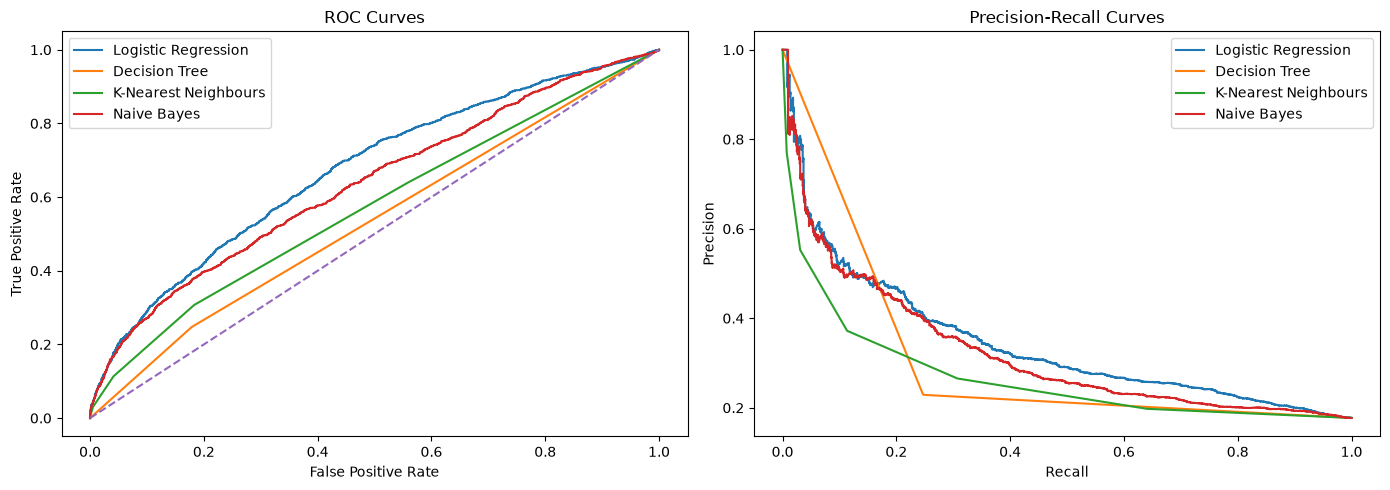

In [132]:
from sklearn.metrics import roc_curve, precision_recall_curve

model_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": decision_tree_probabilities,
    "K-Nearest Neighbours": knn_probabilities,
    "Naive Bayes": naive_bayes_probabilities,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(
        y_test_no_show,
        probabilities,
    )

    axes[0].plot(
        fpr,
        tpr,
        label=model_name,
    )

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

for model_name, probabilities in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(
        y_test_no_show,
        probabilities,
    )

    axes[1].plot(
        recall,
        precision,
        label=model_name,
    )

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

majority_prediction = np.zeros(
    len(y_test_no_show),
    dtype=int
)

majority_probability = np.zeros(
    len(y_test_no_show)
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)

results = []

results.append({
    "model": "Majority Baseline",
    "accuracy": accuracy_score(
        y_test_no_show,
        majority_prediction,
    ),
    "precision": precision_score(
        y_test_no_show,
        majority_prediction,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test_no_show,
        majority_prediction,
        zero_division=0,
    ),
    "f1": f1_score(
        y_test_no_show,
        majority_prediction,
        zero_division=0,
    ),
    "pr_auc": np.nan,
})

models = {
    "Logistic Regression": (
        logistic_predictions,
        logistic_probabilities,
    ),
    "Decision Tree": (
        decision_tree_predictions,
        decision_tree_probabilities,
    ),
    "K-Nearest Neighbours": (
        knn_predictions,
        knn_probabilities,
    ),
    "Naive Bayes": (
        naive_bayes_predictions,
        naive_bayes_probabilities,
    ),
}

for name, (predictions, probabilities) in models.items():

    results.append({
        "model": name,
        "accuracy": accuracy_score(
            y_test_no_show,
            predictions,
        ),
        "precision": precision_score(
            y_test_no_show,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_test_no_show,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_test_no_show,
            predictions,
            zero_division=0,
        ),
        "pr_auc": average_precision_score(
            y_test_no_show,
            probabilities,
        ),
    })

comparison = pd.DataFrame(results)

comparison

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

false_positive_cost = 500
false_negative_cost = 5000

thresholds = np.arange(
    0.01,
    1.00,
    0.01,
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        logistic_probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_no_show,
        predictions,
        labels=[0, 1],
    ).ravel()

    total_cost = (
        fp * false_positive_cost
        + fn * false_negative_cost
    )

    threshold_results.append({
        "threshold": threshold,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "total_cost_xaf": total_cost,
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

In [ ]:
best_threshold = threshold_results.loc[
    threshold_results["total_cost_xaf"].idxmin()
]

best_threshold

In [ ]:
threshold_distance = abs(
    best_threshold["threshold"] - 0.50
)

threshold_distance

In [ ]:
from sklearn.metrics import brier_score_loss

brier_before = brier_score_loss(
    y_test_no_show,
    logistic_probabilities,
)

brier_before

In [ ]:
from sklearn.linear_model import LogisticRegression

platt_model = LogisticRegression(
    random_state=42
)

platt_model.fit(
    logistic_model.predict_proba(X_train_encoded)[:, 1].reshape(-1, 1),
    y_train_no_show,
)

calibrated_probabilities = platt_model.predict_proba(
    logistic_probabilities.reshape(-1, 1)
)[:, 1]

In [ ]:
brier_after = brier_score_loss(
    y_test_no_show,
    calibrated_probabilities,
)

brier_change = brier_after - brier_before

brier_after, brier_change

In [ ]:
from sklearn.calibration import calibration_curve

prob_true_before, prob_pred_before = calibration_curve(
    y_test_no_show,
    logistic_probabilities,
    n_bins=10,
    strategy="uniform",
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test_no_show,
    calibrated_probabilities,
    n_bins=10,
    strategy="uniform",
)

plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="Before Platt scaling",
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="After Platt scaling",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration",
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve — Logistic Regression")
plt.legend()
plt.show()

In [ ]:
test_dates = appointments.loc[
    X_test.index,
    "scheduled_ts"
]

test_dates = pd.to_datetime(
    test_dates,
    format="mixed",
    dayfirst=True,
    errors="coerce",
)

weeks = (
    test_dates.max() - test_dates.min()
).days / 7

reminder_calls = (
    best_threshold["false_positives"]
    + best_threshold["true_positives"]
)

reminder_calls_per_week = (
    reminder_calls / weeks
)

weeks, reminder_calls, reminder_calls_per_week